# Beacon HTO Demultiplexing Tutorial

## Bar11 Dataset Example

This tutorial demonstrates how to use Beacon to demultiplex hashtag oligonucleotide (HTO) data. The Bar11 dataset contains 11 cell lines labeled with MULTI-seq barcodes

### Installation

In [1]:
devtools::install_github('cheryl-xiang/BeaconTest')
library(BeaconTest)

# Used for tutorial, not needed for beacon_calls()
library(ggplot2)
library(dplyr)
library(tidyr)
library(viridis)
library(patchwork)
library(Seurat)

Warning message:
“`install_github()` was deprecated in devtools 2.5.0.
ℹ Please use pak::pak("user/repo") instead.”
Using GitHub PAT from the git credential store.




── R CMD build ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
✔  checking for file ‘/private/var/folders/5j/gy3kvrts21bg9h0mjxn2bwww0000gn/T/RtmpySFTcY/remotes91faa7692c4/cheryl-xiang-BeaconTest-9f90744/DESCRIPTION’
─  preparing ‘BeaconTest’:
✔  checking DESCRIPTION meta-information
─  checking for LF line-endings in source and make files and shell scripts
─  checking for empty or unneeded directories
─  looking to see if a ‘data/datalist’ file should be added
─  building ‘BeaconTest_0.0.0.9000.tar.gz’
   



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: viridisLite

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.5.2 but the current version is
4.5.3; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




### Data Loading

The HTO count matrix should have HTOs as rows and cells as columns

In [2]:
# Load HTO count matrix
hto_count <- read.csv('data/barcodes_matrix_filtered_bar11.csv', row.names = 1)
hto_count <- as.matrix(hto_count)
hto_count <- hto_count[, !colnames(hto_count) %in% c('nUMI', 'nUMI_total')]
hto_count <- t(hto_count)

cat('HTOs:', nrow(hto_count), '\n')
cat('Cells:', ncol(hto_count), '\n')
cat('Rows: ', rownames(hto_count), '\n')

# Load scoring data
load('data/bar11_scores.RData')

cat('Seurat object dimensions:', dim(seurat), '\n')
cat('UMAP available:', 'umap' %in% names(seurat@reductions), '\n')

HTOs: 11 
Cells: 5722 
Rows:  Bar1 Bar2 Bar3 Bar4 Bar5 Bar6 Bar7 Bar8 Bar9 Bar10 Bar11 
Seurat object dimensions: 36601 4162 
UMAP available: TRUE 


### Set Parameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| sig_max | 3 | Maximum signal threshold |
| min_count | 2 | Minimum count filter |
| max_bf | 0.97 | Maximum Bayes factor |
| max_iter | 30 | Maximum iterations |

In [3]:
params <- list()
params$sig_max <- 3
params$min_count <- 2
params$max_bf <- 0.97
params$max_iter <- 30

### Run Beacon

`beacon_calls()` returns a named vector of numeric assignments:
- `1-N` = singlet assigned to barcode N
- `1000` = doublet/multiplet
- `0` = negative

In [4]:
calls <- beacon_calls(hto_count, params)

[1] "Solving initial parameters..."
[1] "Iteration 1..."
Joint log-likelihood = -227542
[1] "Iteration 2..."
Joint log-likelihood = -222649
[1] "Iteration 3..."
Joint log-likelihood = -222554
[1] "Iteration 4..."
Joint log-likelihood = -222553
[1] "Parameters converged!"


In [5]:
# Summary
cat('Summary of results: \n', '\n')
cat('Singlets:', sum(calls > 0 & calls < 1000), '\n')
cat('Doublets:', sum(calls == 1000), '\n')
cat('Negatives:', sum(calls == 0), '\n')
cat('Total:', length(calls), '\n')

Summary of results: 
 
Singlets: 5125 
Doublets: 252 
Negatives: 345 
Total: 5722 


### Visualize on UMAP

In [6]:
# Map numeric calls to sample names
labels <- sample_labels <- c('CAL27', 'BJ', '293T', 'M231', 'HEPG2', 'HCT116', 
                   'HEP3', 'A549', 'SCC13', 'LNCAP', 'A431', 'Doublet', 'Negative')

# Assign colors
cols <- c(
  'CAL27'    = '#4E79A7',
  'BJ'       = '#F28E2B',
  '293T'     = '#59A14F',
  'M231'     = '#E15759',
  'HEPG2'   = '#B6992D',
  'HCT116'  = '#499894',
  'HEP3'    = '#D37295',
  'A549'    = '#B07AA1',
  'SCC13'   = '#9D7660',
  'LNCAP'   = '#86BCB6',
  'A431'    = '#FABFD2',
  'Doublet' = 'gray80',
  'Negative' = 'black'
)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4162
Number of edges: 131349

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9965
Number of communities: 12
Elapsed time: 0 seconds

 Manually combining clusters 11 and 3...

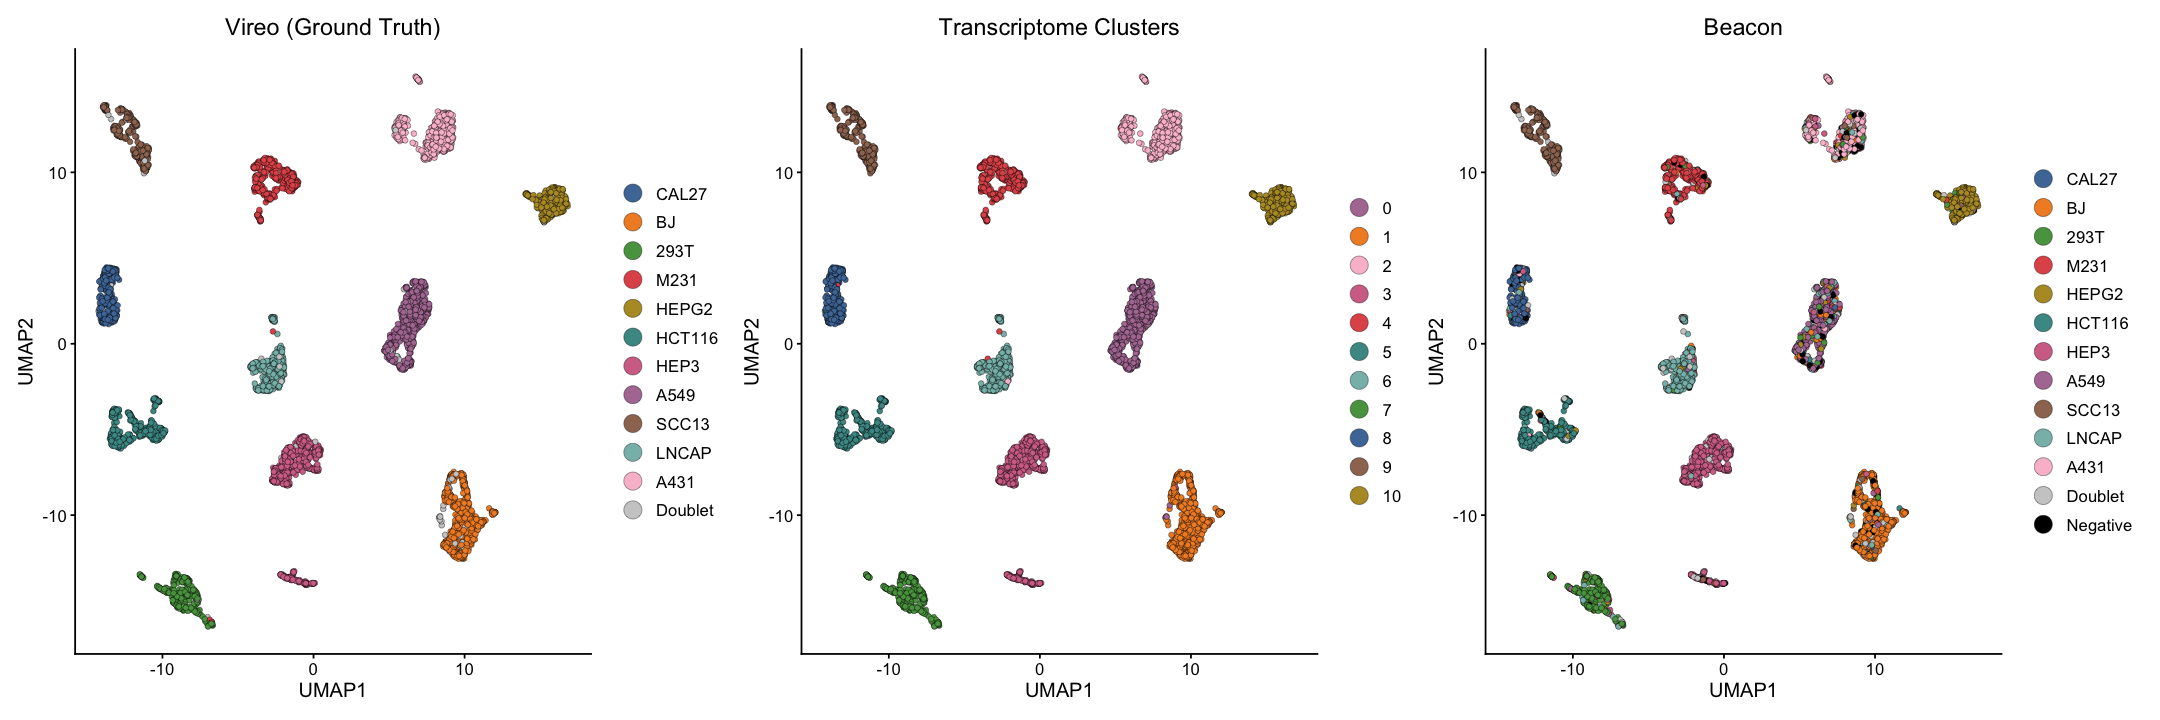

In [7]:
umap_df <- as.data.frame(Embeddings(seurat, 'umap'))

# Vireo
seurat$vireo <- factor(
  truth_bar11_vireo,
  levels = c(1:11, 1000, 0),
  labels = labels
)
umap_df$vireo <- seurat$vireo

p_vireo <- ggplot(umap_df, aes(x = umap_1, y = umap_2)) +
  geom_point(aes(fill = vireo), shape = 21, color = 'black', stroke = 0.15, size = 1.5) +
  scale_fill_manual(values = cols) +
  labs(x = 'UMAP1', y = 'UMAP2', title = 'Vireo (Ground Truth)') +
  guides(fill = guide_legend(override.aes = list(size = 5))) +
  theme_classic() +
  theme(
    plot.title = element_text(size = 14, hjust = 0.5),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
    legend.title = element_blank(),
    legend.text = element_text(size = 10)
  )

# Transciptome Clusters
seurat <- FindNeighbors(seurat, dims = 1:30)
seurat <- FindClusters(seurat, resolution = 0.03)

cat('\n', 'Manually combining clusters 11 and 3...')
seurat$seurat_clusters[seurat$seurat_clusters == 11] <- 3
seurat$seurat_clusters <- droplevels(seurat$seurat_clusters)

cols_rna <- c(
  "8"   = "#4E79A7",
  "1"      = "#F28E2B",
  "7"    = "#59A14F",
  "4"    = "#E15759",
  "10"   = "#B6992D",
  "5"  = "#499894",
  "3"    = "#D37295",
  "0"    = "#B07AA1",
  "9"   = "#9D7660",
  "6"   = "#86BCB6",
  "2"    = "#FABFD2"
)

umap_df$rna <- seurat$seurat_clusters

p_rna <- ggplot(umap_df, aes(x = umap_1, y = umap_2)) +
  geom_point(aes(fill = rna), shape = 21, color = 'black', stroke = 0.15, size = 1.5) +
  scale_fill_manual(values = cols_rna) +
  labs(x = 'UMAP1', y = 'UMAP2', title = 'Transcriptome Clusters') +
  guides(fill = guide_legend(override.aes = list(size = 5))) +
  theme_classic() +
  theme(
    plot.title = element_text(size = 14, hjust = 0.5),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
    legend.title = element_blank(),
    legend.text = element_text(size = 10)
  )

# Beacon
seurat$beacon <- factor(
  calls[colnames(seurat)],
  levels = c(1:11, 1000, 0),
  labels = labels
)
umap_df$beacon <- seurat$beacon

p_beacon <- ggplot(umap_df, aes(x = umap_1, y = umap_2)) +
  geom_point(aes(fill = beacon), shape = 21, color = 'black', stroke = 0.15, size = 1.5) +
  scale_fill_manual(values = cols) +
  labs(x = 'UMAP1', y = 'UMAP2', title = 'Beacon') +
  guides(fill = guide_legend(override.aes = list(size = 5))) +
  theme_classic() +
  theme(
    plot.title = element_text(size = 14, hjust = 0.5),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
    legend.title = element_blank(),
    legend.text = element_text(size = 10)
  )

# Combined
options(repr.plot.width = 18, repr.plot.height = 6)
p_vireo + p_rna + p_beacon + plot_layout(ncol = 3)

### Confusion Matrix

Compare Beacon assignments against Vireo ground truth

In [8]:
#vireo has filtered out cells?
print(length(truth_bar11_vireo))
print(length(calls))

[1] 4162
[1] 5722


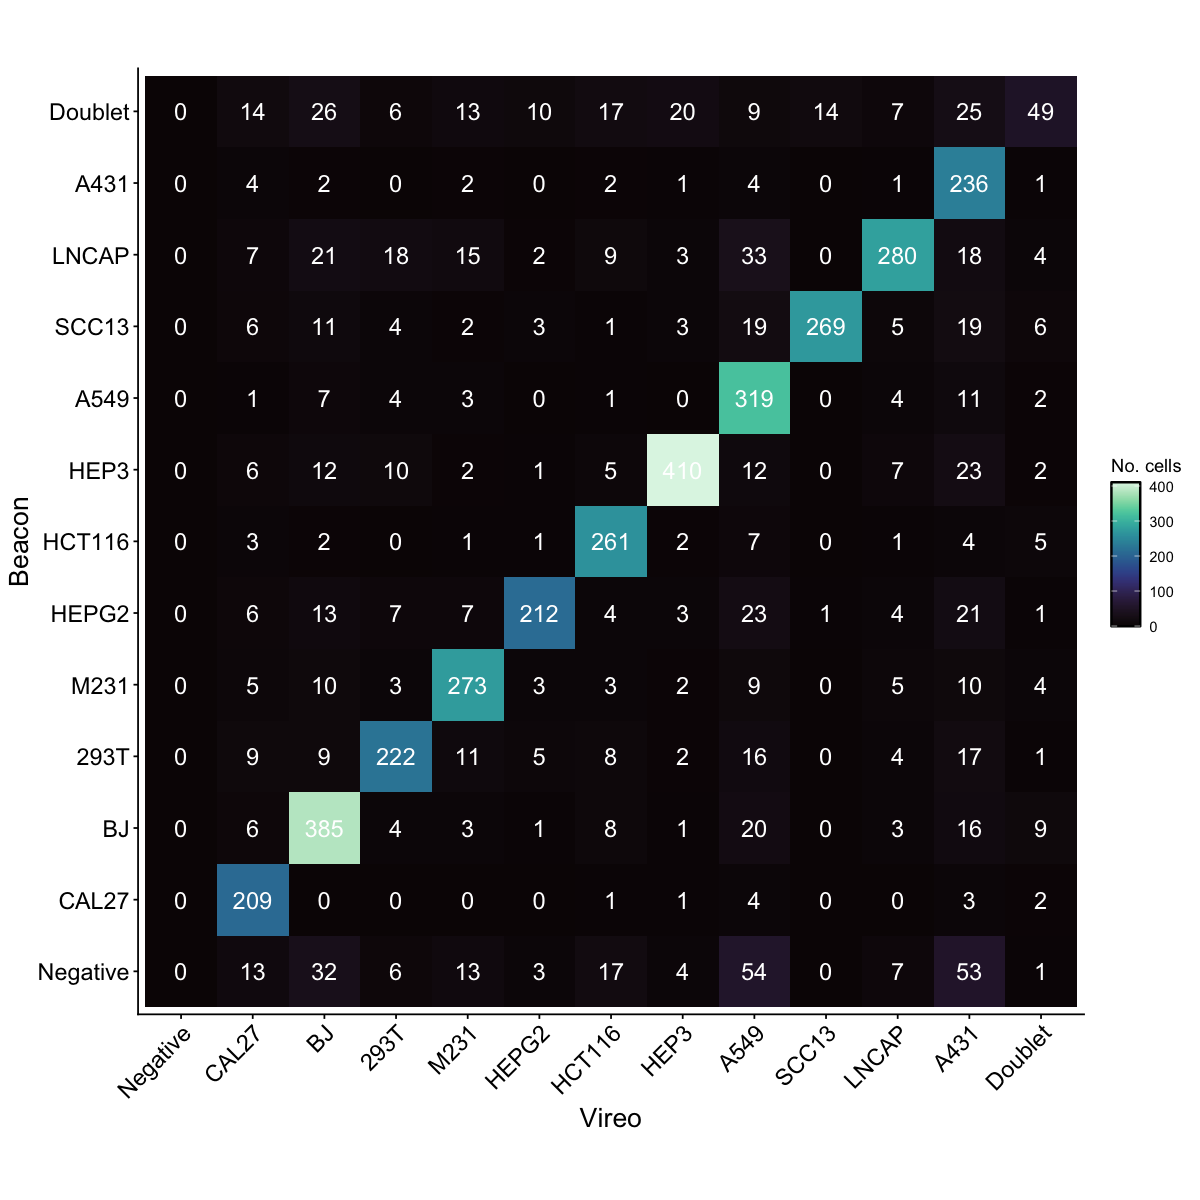

In [9]:
# Vireo vs. Beacon Calls
labels <- c('Negative', 'CAL27', 'BJ', '293T', 'M231', 'HEPG2', 'HCT116',
            'HEP3', 'A549', 'SCC13', 'LNCAP', 'A431', 'Doublet')

common_cells <- intersect(names(truth_bar11_vireo), names(calls))
vireo_conf <- factor(truth_bar11_vireo[common_cells], levels = c(0:11, 1000), labels = labels)
beacon_conf <- factor(calls[common_cells], levels = c(0:11, 1000), labels = labels)

confusion <- table(Vireo = vireo_conf, Beacon = beacon_conf)
df_confusion <- as.data.frame(confusion)

options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(df_confusion, aes(Vireo, Beacon, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq), size = 5, color = 'white') +
  scale_fill_gradientn(
    colours = viridis::mako(256),
    name = 'No. cells',
    guide = guide_colorbar(frame.colour = 'black', frame.linewidth = 0.7)
  ) +
  coord_equal() +
  theme_classic() +
  labs(x = 'Vireo', y = 'Beacon') +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 14),
    axis.text.y = element_text(size = 14),
    axis.title = element_text(size = 16)
  )

Compare transcriptome clusters with Vireo ground truth

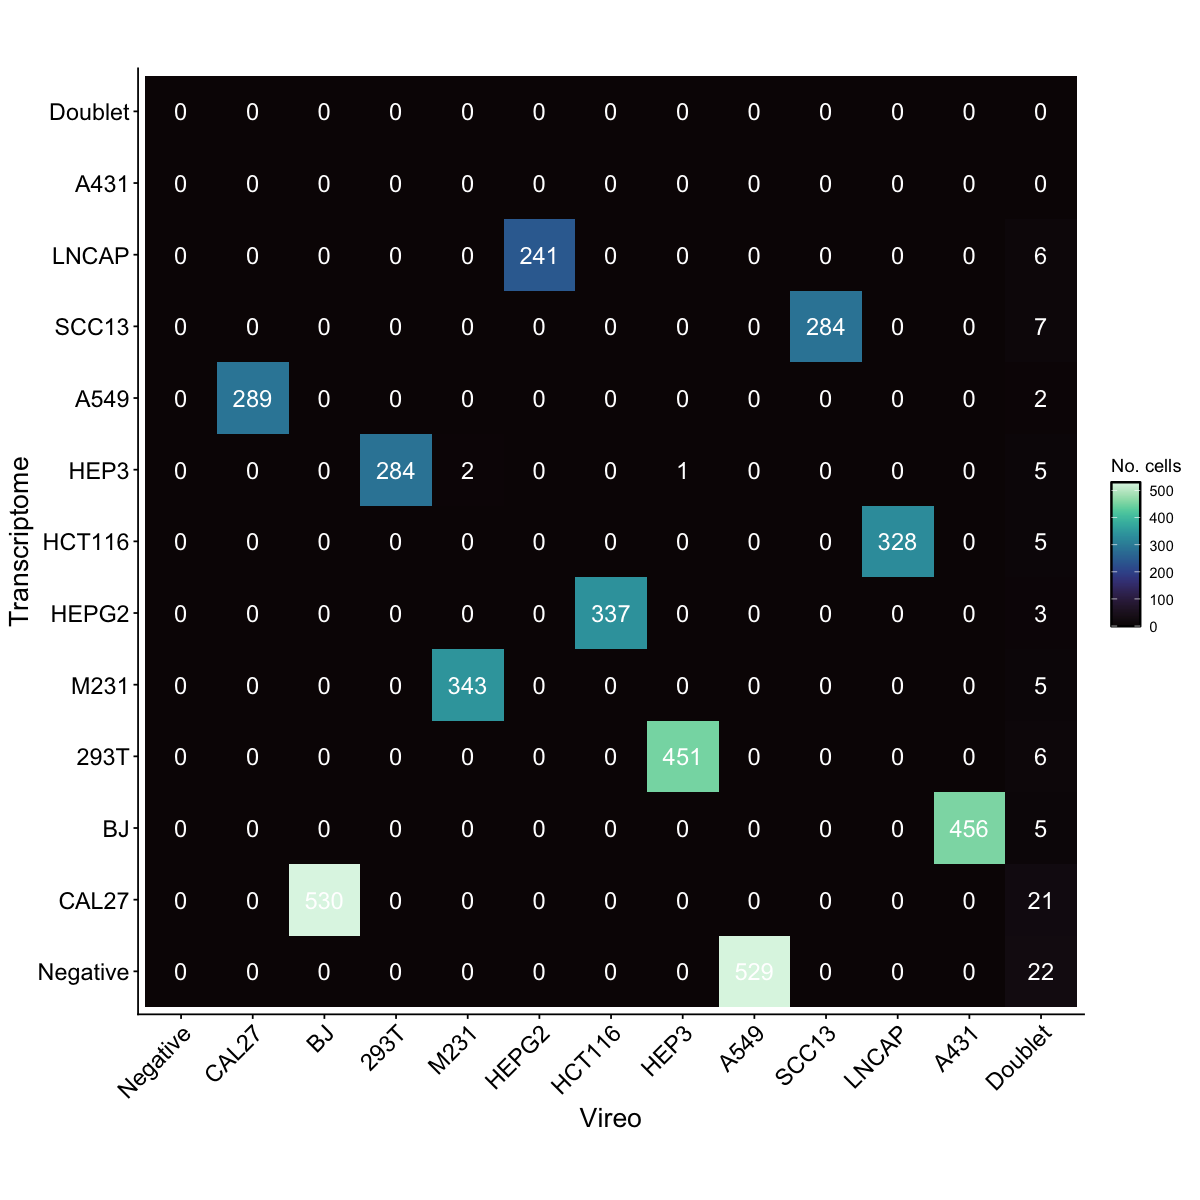

In [10]:
common_cells <- intersect(names(truth_bar11_vireo), names(seurat$seurat_clusters))
vireo_conf <- factor(truth_bar11_vireo[common_cells], levels = c(0:11, 1000), labels = labels)
rna_conf <- factor(seurat$seurat_clusters[common_cells], levels = c(0:11, 1000), labels = labels)

confusion <- table(Vireo = vireo_conf, Transcriptome = rna_conf)
df_confusion <- as.data.frame(confusion)

options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(df_confusion, aes(Vireo, Transcriptome, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq), size = 5, color = 'white') +
  scale_fill_gradientn(
    colours = viridis::mako(256),
    name = 'No. cells',
    guide = guide_colorbar(frame.colour = 'black', frame.linewidth = 0.7)
  ) +
  coord_equal() +
  theme_classic() +
  labs(x = 'Vireo', y = 'Transcriptome') +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 14),
    axis.text.y = element_text(size = 14),
    axis.title = element_text(size = 16)
  )

### Scores

Calculate scores for Beacon

In [13]:
bars <- bars_bar11
weights <- weights_bar11
truth <- truth_bar11_vireo

common_cells <- intersect(names(truth), names(calls))
tr <- truth[common_cells]
pr <- calls[common_cells]

scores <- data.frame(
  Metric = c('F1 Micro', 'F1 Macro', 'F1 Weighted', 'MCC', 'Concordance'),
  Score = round(c(
    f1_micro(tr, pr),
    f1_macro(tr, pr, bars),
    f1_weighted(tr, pr, bars, weights),
    mcc(tr, pr, bars),
    concordance(tr, pr)
  ), 3)
)

scores

Metric,Score
<chr>,<dbl>
F1 Micro,0.770
F1 Macro,0.749
F1 Weighted,0.773
MCC,0.732
Concordance,0.751


### Per-Sample F1 Scores

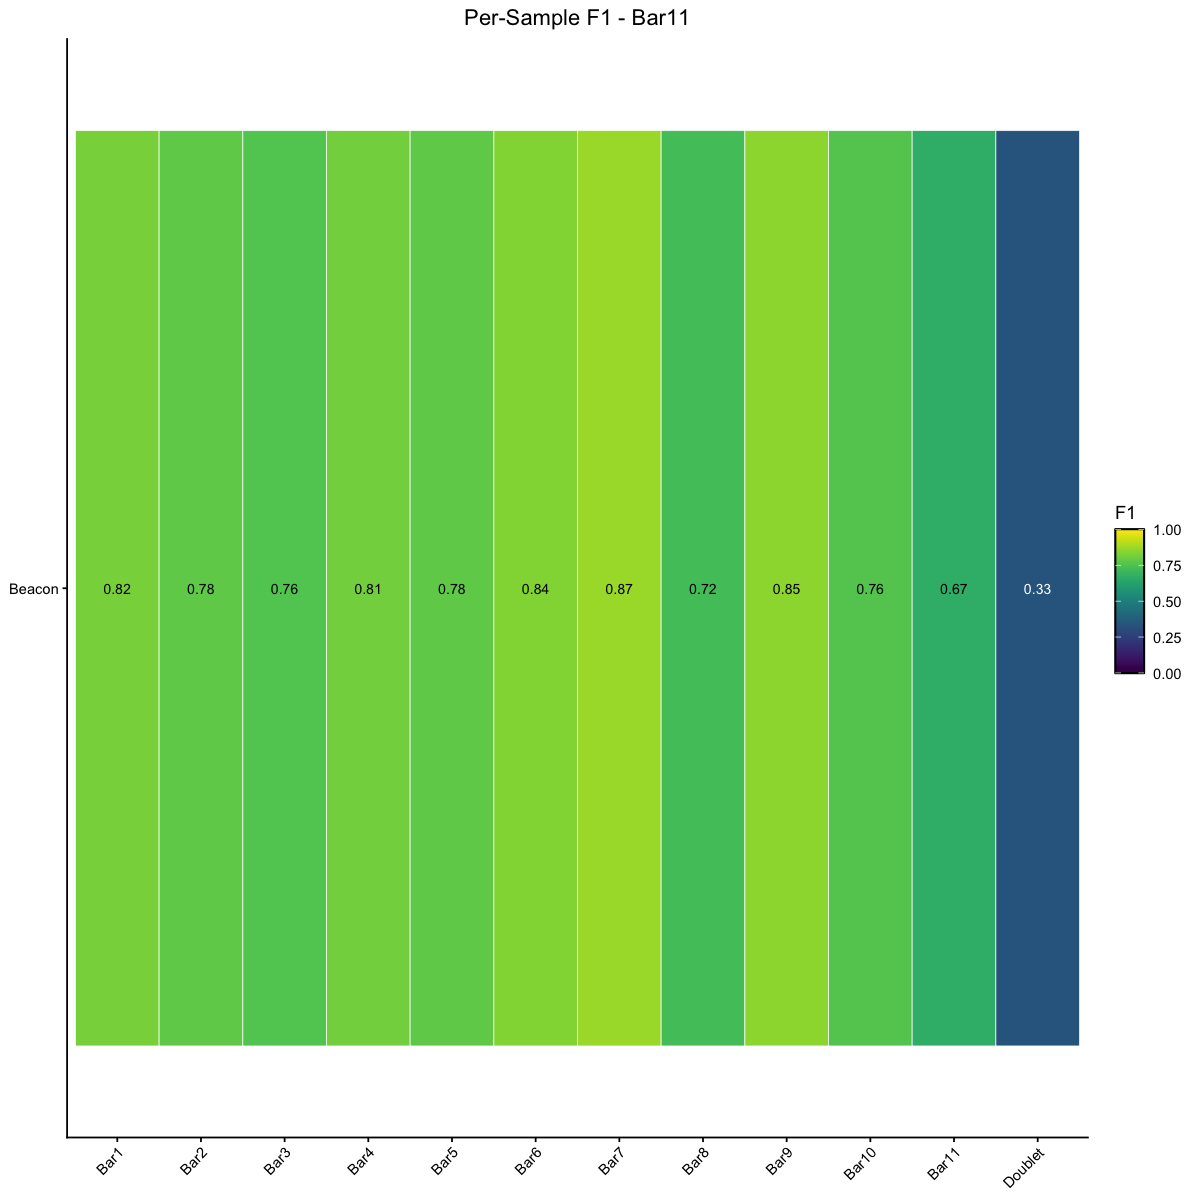

In [15]:
barcode_names <- c('Bar1', 'Bar2', 'Bar3', 'Bar4', 'Bar5', 'Bar6',
                   'Bar7', 'Bar8', 'Bar9', 'Bar10', 'Bar11', 'Doublet')

f1_per_sample <- f1_scores(tr, pr, bars)

f1_df <- data.frame(
  Barcode = factor(barcode_names, levels = barcode_names),
  F1 = f1_per_sample,
  Method = 'Beacon'
)

ggplot(f1_df, aes(x = Barcode, y = Method, fill = F1)) +
  geom_tile(color = 'white') +
  geom_text(aes(label = sprintf('%.2f', F1), color = F1 < 0.5), size = 3) +
  scale_color_manual(values = c('FALSE' = 'black', 'TRUE' = 'white'), guide = 'none') +
  scale_fill_gradientn(
    colours = viridis::viridis(256),
    limits = c(0, 1),
    na.value = 'grey90',
    name = 'F1',
    guide = guide_colorbar(frame.colour = 'black', frame.linewidth = 0.6)
  ) +
  theme_classic() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title = element_blank()
  ) +
  labs(title = 'Per-Sample F1 - Bar11')